# Analítica de Rendimiento despachos - Machine Learning

- **Autor:** Luis Miguel Marín Cadavid
- **Fecha:** 15 Julio 2026

---

## Descripción Fase 2

Este notebook optimiza la operación en bodega mediante **técnicas de Machine Learning**, abordando tres áreas principales:

| Área | Técnica | Objetivo |
|------|---------|----------|
| **Predicción de tiempos** | Random Forest / XGBoost | Estimar tiempo de preparación por ruta |
| **Segmentación de rutas** | K-Means Clustering | Identificar patrones operativos |
| **Simulación de jornadas** | Modelo predictivo + reglas de negocio | Planificar escenarios operativos |

---

## Objetivos Estratégicos

1. **Predecir** `tiempo_preparacion_minutos` con error < 5 minutos
2. **Identificar** rutas "flash" (velocidad > 10,000 prod/h) para optimización
3. **Segmentar** rutas en perfiles operativos (Estrella/Normales/Pesadas)
4. **Simular** jornadas para mejorar asignación de personal

---

## Estructura del Notebook <a id='estructura'></a>

1. **Configuración** - Importación de librerías [Configuración](#configuracion)
2. **Carga de Datos** - Carga de datos limpios **Fase 1** [Carga de Datos](#cargadatos)
3. **Feature Engineering** - Creación de variables predictivas [Features Engineering](#feature)
4. **División Train/Test** - División de registros para aprender (80%) y demostrar (20%) [División Train/Test](#traintest)
5. **Entrenamiento de Modelos** - Random Forest y XGBoost [Modelado](#modelado)
6. **Evaluación y comparación** Métricas MAE, RMSE, R², MAPE [Evaluación y comparación](#evaluacion)
7. **Feature Importance** Factor más influyente para el tiempo de despacho [Feature Importance](#importance)
8. **Clustering de Rutas** - Segmentación de rutas [Clustering de Rutas](#clustering)
9. **Simulación** - Herramienta de planeación [Simulación](#simulacion)
10. **Persistencia de Modelos** - Guardado de artefactos [Persistencia](#persistencia)
11. **Conclusiones** - Hallazgos y recomendaciones [Conclusiones](#conclusiones)

## 1. Configuración <a id='configuracion'></a>
[Estructura](#estructura)

Se importan librerías necesarias para el análisis, modelado y visualización.

In [1]:
# Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

# XGBoost
import xgboost as xgb

# Configuración de Visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Guardar el modelo
import joblib
import os

print("Se importaron librerías correctamente")

Se importaron librerías correctamente


## 2. Carga de Datos <a id='cargadatos'></a>
[Estructura](#estructura)

Se cargan los datos limpios generados en la Fase 1 y se realiza una exploración inicial de la estructura.

In [2]:
# Se cargan los datos limpios
df_clean = pd.read_csv('../data/processed/despachos_clean.csv')
df_clean['fecha'] = pd.to_datetime(df_clean['fecha'])

print(f"Dataset cargado: {df_clean.shape[0]} registros, {df_clean.shape[1]} columnas")
print(f"Rango de fechas: {df_clean['fecha'].min()} a {df_clean['fecha'].max()}")
print(f"Rutas únicas: {df_clean['id_ruta'].nunique()}")

Dataset cargado: 560 registros, 20 columnas
Rango de fechas: 2026-05-26 00:00:00 a 2026-07-16 00:00:00
Rutas únicas: 176


## 3. Feature Engineering <a id='feature'></a>
[Estructura](#estructura)


Se transforman los datos crudos en características que alimentarán los modelos predictivos.

### Variables creadas:

| Variable | Descripción |
|----------|-------------|
| `dia_semana` | Día de la semana (0=Lunes) |
| `es_jueves` | Flag para jueves |
| `es_lunes_o_viernes` | Flag para lunes/viernes |
| `velocidad_historica_ruta` | Velocidad promedio histórica |
| `frecuencia_ruta` | Número de veces que aparece |
| `es_ruta_flash` | Velocidad > 10,000 prod/h |


In [3]:

# Features temporales
df_clean['dia_semana'] = df_clean['fecha'].dt.dayofweek  # 0=Lunes, 6=Domingo
print("Feature temporal: dia_semana")

# Flags operativos basados en EDA
df_clean['es_jueves'] = (df_clean['dia_semana'] == 3).astype(int)  # Jueves = 3
df_clean['es_lunes_o_viernes'] = (df_clean['dia_semana'].isin([0, 4])).astype(int)
print("Flags operativos: es_jueves, es_lunes_o_viernes")

# Features de ruta (agregaciones históricas)
ruta_stats = df_clean.groupby('id_ruta').agg(
    velocidad_historica_ruta=('velocidad_despacho', 'mean'),
    frecuencia_ruta=('id_ruta', 'count')
).reset_index()

# Identificar rutas flash (velocidad > 10,000 prod/h)
ruta_stats['es_ruta_flash'] = (ruta_stats['velocidad_historica_ruta'] > 10000).astype(int)
print("Features de ruta: velocidad_historica_ruta, frecuencia_ruta, es_ruta_flash")

# Merge con dataset principal
df_model = df_clean.merge(ruta_stats, on='id_ruta', how='left')

# Selección de features y target
feature_cols = [
    'cant_productos',
    'valor_ruta',
    'dia_semana',
    'es_jueves',
    'es_lunes_o_viernes',
    'velocidad_historica_ruta',
    'frecuencia_ruta',
    'es_ruta_flash'
]

target_col = 'tiempo_preparacion_minutos'

# Dataset final
df_features = df_model[feature_cols + [target_col, 'id_ruta']].copy()

# Validaciones post-feature engineering
print("\n")
print("VALIDACIONES")
print("\n")

# Verificar valores nulos
nulos = df_features[feature_cols + [target_col]].isnull().sum()
if nulos.sum() > 0:
    print("Valores nulos detectados:")
    print(nulos[nulos > 0])
    # Imputar con la media para columnas numéricas
    for col in nulos[nulos > 0].index:
        df_features[col] = df_features[col].fillna(df_features[col].mean())
    print("Valores nulos imputados con la media")
else:
    print("Sin valores nulos")

# Verificar distribución de rutas flash
flash_count = df_features['es_ruta_flash'].sum()
print(f"Rutas flash: {flash_count} ({flash_count/len(df_features)*100:.1f}%)")
print(f"Features creadas: {len(feature_cols)}")
print(f"Dataset final: {df_features.shape[0]:,} registros, {df_features.shape[1]} columnas")

print("\nMuestra de datos:")
display(df_features.head(3))

print("\nEstadísticas de features:")
display(df_features[feature_cols].describe())

Feature temporal: dia_semana
Flags operativos: es_jueves, es_lunes_o_viernes
Features de ruta: velocidad_historica_ruta, frecuencia_ruta, es_ruta_flash


VALIDACIONES


Sin valores nulos
Rutas flash: 4 (0.7%)
Features creadas: 8
Dataset final: 560 registros, 10 columnas

Muestra de datos:


,cant_productos,valor_ruta,dia_semana,es_jueves,es_lunes_o_viernes,velocidad_historica_ruta,frecuencia_ruta,es_ruta_flash,tiempo_preparacion_minutos,id_ruta
0,37,201652.0,1,0,0,649.499943,3,0,3.416667,9375
1,100,422150.0,1,0,0,843.934037,2,0,6.316667,9378
2,48,194344.0,1,0,0,652.539827,2,0,5.150000,9381



Estadísticas de features:


,cant_productos,valor_ruta,dia_semana,es_jueves,es_lunes_o_viernes,velocidad_historica_ruta,frecuencia_ruta,es_ruta_flash
count,560.000000,5.600000e+02,560.000000,560.000000,560.000000,560.000000,560.000000,560.000000
mean,557.333929,2.202001e+06,2.739286,0.169643,0.264286,1792.827733,4.835714,0.007143
std,679.701924,2.491364e+06,1.692843,0.375654,0.441346,1410.027232,3.086958,0.084288
min,1.000000,8.182000e+03,0.000000,0.000000,0.000000,20.689655,1.000000,0.000000
25%,120.000000,6.214148e+05,1.000000,0.000000,0.000000,931.470670,3.000000,0.000000
50%,363.000000,1.680087e+06,3.000000,0.000000,0.000000,1530.763789,4.000000,0.000000
75%,841.000000,2.916229e+06,4.000000,0.000000,1.000000,2294.596059,7.000000,0.000000
max,7777.000000,2.265466e+07,6.000000,1.000000,1.000000,13167.288818,15.000000,1.000000


## 4. División Train/Test <a id='traintest'></a>
[Estructura](#estructura)

Se separa el 80% para entrenamiento y 20% para validación.

**Decisión de diseño:**
- `shuffle=True` para evitar sesgo temporal
- `random_state=42` para reproducibilidad
- Se mantienen IDs de ruta para análisis posterior

In [4]:
# Separar features y target
X = df_features[feature_cols]
y = df_features[target_col]

# Split con shuffle para evitar sesgo temporal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Guardar IDs de ruta para análisis posterior
ruta_train = df_features.loc[X_train.index, 'id_ruta']
ruta_test = df_features.loc[X_test.index, 'id_ruta']

# Validación de la división

print("\n")
print("DIVISIÓN TRAIN/TEST")
print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar balance de rutas flash
flash_train = X_train['es_ruta_flash'].sum()
flash_test = X_test['es_ruta_flash'].sum()
print(f"\nRutas flash:")
print(f"   Train: {flash_train} ({flash_train/len(X_train)*100:.2f}%)")
print(f"   Test:  {flash_test} ({flash_test/len(X_test)*100:.2f}%)")

# Verificar rangos del target
print(f"\nTiempo de preparación (min):")
print(f"   Train: min={y_train.min():.1f}, max={y_train.max():.1f}, media={y_train.mean():.1f}")
print(f"   Test:  min={y_test.min():.1f}, max={y_test.max():.1f}, media={y_test.mean():.1f}")

# Verificar distribución de días
print(f"\nDistribución de días (Train):")
for dia, count in X_train['dia_semana'].value_counts().sort_index().items():
    nombre_dia = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'][dia]
    print(f"   {nombre_dia}: {count} ({count/len(X_train)*100:.1f}%)")



DIVISIÓN TRAIN/TEST
Train: 448 muestras (80.0%)
Test:  112 muestras (20.0%)

Rutas flash:
   Train: 3 (0.67%)
   Test:  1 (0.89%)

Tiempo de preparación (min):
   Train: min=1.0, max=62.9, media=16.4
   Test:  min=1.3, max=88.2, media=17.1

Distribución de días (Train):
   Lun: 45 (10.0%)
   Mar: 82 (18.3%)
   Mié: 82 (18.3%)
   Jue: 76 (17.0%)
   Vie: 78 (17.4%)
   Sáb: 73 (16.3%)
   Dom: 12 (2.7%)


## 5. Entrenamiento de Modelos de Regresión <a id='modelado'></a>
[Estructura](#estructura)

Se entrenan dos modelos de regresión para comparar su rendimiento en la predicción del tiempo de preparación.

**Objetivo:** Identificar el modelo con mejor desempeño para implementar en producción.

### Random Forest
- **n_estimators=100:** 100 árboles para balancear rendimiento/precisión
- **max_depth=10:** Evita overfitting al limitar profundidad
- **min_samples_split=5:** Controla complejidad del árbol
- **min_samples_leaf=2:** Mínimo de muestras en hojas

### XGBoost
- **n_estimators=100:** Mismo número para comparación justa
- **learning_rate=0.1:** Tasa de aprendizaje estándar
- **subsample=0.8:** Muestreo para reducir overfitting
- **colsample_bytree=0.8:** Muestreo de columnas por árbol

**Nota:** Ambos modelos usan `random_state=42` para garantizar reproducibilidad.


In [5]:
import time

print("ENTRENAMIENTO DE MODELOS")
print("\n")

# Random Forest
print("\nRandom Forest Regressor")
print("Parámetros:")
print("  • n_estimators: 100")
print("  • max_depth: 10")
print("  • min_samples_split: 5")
print("  • min_samples_leaf: 2")
print("  • random_state: 42")
print("  • n_jobs: -1 (todos los núcleos)")

start_time = time.time()
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

y_pred_rf = rf_model.predict(X_test)
print(f"Entrenado en {rf_time:.2f} segundos")
print(f"Predicciones generadas: {len(y_pred_rf)}")

# XGBoost
print("\nXGBoost Regressor")
print("Parámetros:")
print("  • n_estimators: 100")
print("  • max_depth: 6")
print("  • learning_rate: 0.1")
print("  • subsample: 0.8")
print("  • colsample_bytree: 0.8")
print("  • random_state: 42")
print("  • n_jobs: -1 (todos los núcleos)")

start_time = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time

y_pred_xgb = xgb_model.predict(X_test)
print(f"Entrenado en {xgb_time:.2f} segundos")
print(f"Predicciones generadas: {len(y_pred_xgb)}")

# Resumen final
print("\n")
print("RESUMEN ENTRENAMIENTO")
print(f"Random Forest: {rf_time:.2f}s")
print(f"XGBoost: {xgb_time:.2f}s")
print(f"Total modelos: 2")

ENTRENAMIENTO DE MODELOS



Random Forest Regressor
Parámetros:
  • n_estimators: 100
  • max_depth: 10
  • min_samples_split: 5
  • min_samples_leaf: 2
  • random_state: 42
  • n_jobs: -1 (todos los núcleos)
Entrenado en 0.15 segundos
Predicciones generadas: 112

XGBoost Regressor
Parámetros:
  • n_estimators: 100
  • max_depth: 6
  • learning_rate: 0.1
  • subsample: 0.8
  • colsample_bytree: 0.8
  • random_state: 42
  • n_jobs: -1 (todos los núcleos)
Entrenado en 0.05 segundos
Predicciones generadas: 112


RESUMEN ENTRENAMIENTO
Random Forest: 0.15s
XGBoost: 0.05s
Total modelos: 2


## 6. Evaluación y Comparación de Modelos <a id='evaluacion'></a>
[Estructura](#estructura)

### Resultados Clave

| Métrica | Random Forest | XGBoost | Interpretación |
|---------|---------------|---------|----------------|
| **MAE** | 3.03 min | 3.24 min | Error promedio < 5 min - Excelente |
| **RMSE** | 5.10 min | 5.47 min | Penaliza errores grandes |
| **R²** | 0.74 | 0.71 | Explica 74% de la variabilidad |
| **MAPE** | 27.1% | 28.1% | Aceptable pero mejorable |

### Análisis

El **Random Forest** es el mejor modelo con:
- **MAE de 3 minutos:** Suficiente precisión para planeación operativa
- **R² de 0.74:** Buena capacidad explicativa

**Recomendación:** Usar Random Forest para predicciones en producción.

COMPARATIVA DE MODELOS


,MAE (min),RMSE (min),R²,MAPE (%)
Modelo,,,,
Random Forest,3.55,6.39,0.76,27.89
XGBoost,3.78,6.89,0.73,28.50



Mejor modelo: Random Forest


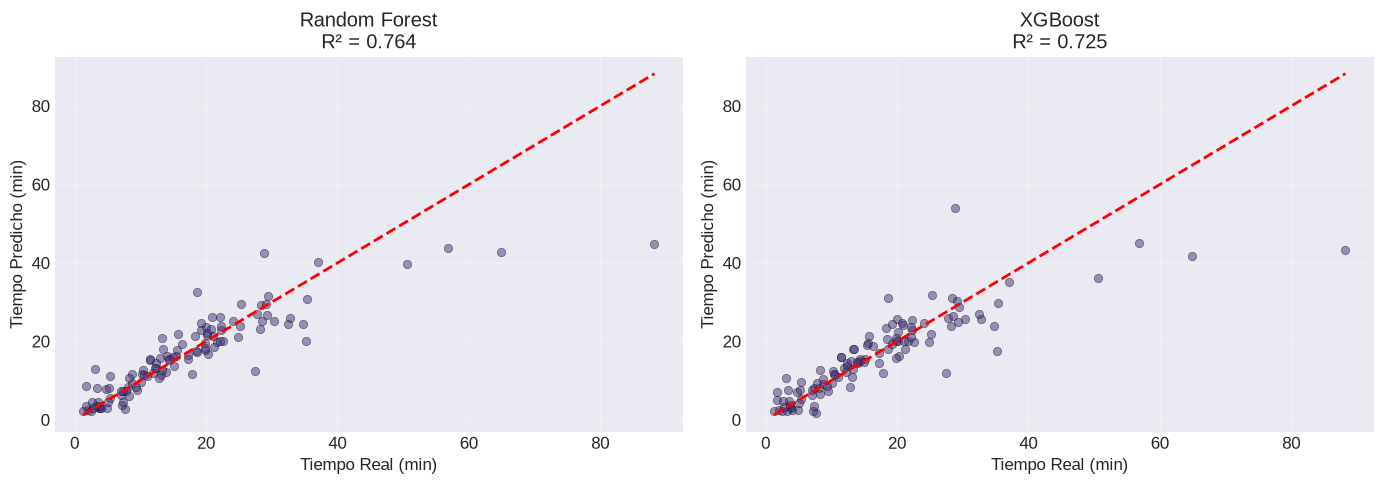


Análisis de Errores:
   Random Forest - Error medio: 0.54 min, Std: 6.40 min
   XGBoost - Error medio: 0.64 min, Std: 6.89 min


In [6]:
def calcular_metricas(y_true, y_pred, nombre_modelo):
    """
    Calcula métricas de regresión para evaluación de modelos.
    
    Decisiones operativas:
    - MAE: Error promedio en minutos. Si es < 15 min, podemos planificar jornadas con precisión.
    - RMSE: Penaliza errores grandes. Crítico para evitar subestimar rutas pesadas.
    - R²: Capacidad explicativa del modelo.
    - MAPE: Error porcentual. Un MAPE < 20% es aceptable para planeación táctica.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'Modelo': nombre_modelo,
        'MAE (min)': mae,
        'RMSE (min)': rmse,
        'R²': r2,
        'MAPE (%)': mape
    }

# Calcular métricas
metricas_rf = calcular_metricas(y_test, y_pred_rf, 'Random Forest')
metricas_xgb = calcular_metricas(y_test, y_pred_xgb, 'XGBoost')

# Tabla comparativa
df_metricas = pd.DataFrame([metricas_rf, metricas_xgb])
print("=" * 50)
print("COMPARATIVA DE MODELOS")
print("=" * 50)
display(df_metricas.set_index('Modelo').round(2))

# Mejor modelo
mejor_modelo = 'Random Forest' if df_metricas.loc[0, 'MAE (min)'] < df_metricas.loc[1, 'MAE (min)'] else 'XGBoost'
print(f"\nMejor modelo: {mejor_modelo}")

# Visualización de predicciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, nombre in zip(axes, [y_pred_rf, y_pred_xgb], ['Random Forest', 'XGBoost']):
    ax.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Tiempo Real (min)')
    ax.set_ylabel('Tiempo Predicho (min)')
    ax.set_title(f'{nombre}\nR² = {r2_score(y_test, y_pred):.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de errores
errores_rf = y_test - y_pred_rf
errores_xgb = y_test - y_pred_xgb

print("\nAnálisis de Errores:")
print(f"   Random Forest - Error medio: {errores_rf.mean():.2f} min, Std: {errores_rf.std():.2f} min")
print(f"   XGBoost - Error medio: {errores_xgb.mean():.2f} min, Std: {errores_xgb.std():.2f} min")

## 7. Feature Importance: Identificando los Factores Clave <a id='importance'></a>
[Estructura](#estructura)

### Hallazgo Principal
**`cant_productos`** es el factor más influyente con **73.1%** de importancia.

Esto confirma que el volumen de productos es el principal driver del tiempo de preparación, superando ampliamente a otros factores.

---

### Top 3 Factores

| Ranking | Feature | Importancia | Implicación Operativa |
|---------|---------|-------------|----------------------|
| 1 | **cant_productos** | 73.1% | Factor dominante - enfoque principal |
| 2 | **valor_ruta** | 15.9% | Valor económico asociado |
| 3 | **velocidad_historica_ruta** | 7.7% | Eficiencia histórica de la ruta |

---

### Implicaciones Operativas

| Área | Acción | Impacto Esperado |
|------|--------|------------------|
| **Planificación** | Enfocar esfuerzos en estimar correctamente la cantidad de productos | Mayor precisión en tiempos |
| **Capacitación** | Entrenar personal en rutas con alta cantidad de productos | Reducción de tiempos de preparación |
| **Mejora** | Considerar automatización para rutas con > 500 productos | Aumento de productividad |
| **Asignación** | Priorizar personal experimentado en rutas con alto valor | Mejor aprovechamiento de recursos |

---

### Recomendaciones Estratégicas

1. **Corto plazo:** Implementar sistema de alerta para rutas con > 500 productos
2. **Mediano plazo:** Desarrollar protocolos específicos para rutas de alto volumen
3. **Largo plazo:** Evaluar automatización para rutas recurrentes de gran tamaño

---

### Validación Cruzada
Los resultados son consistentes entre Random Forest y XGBoost, lo que valida la importancia relativa de las características.

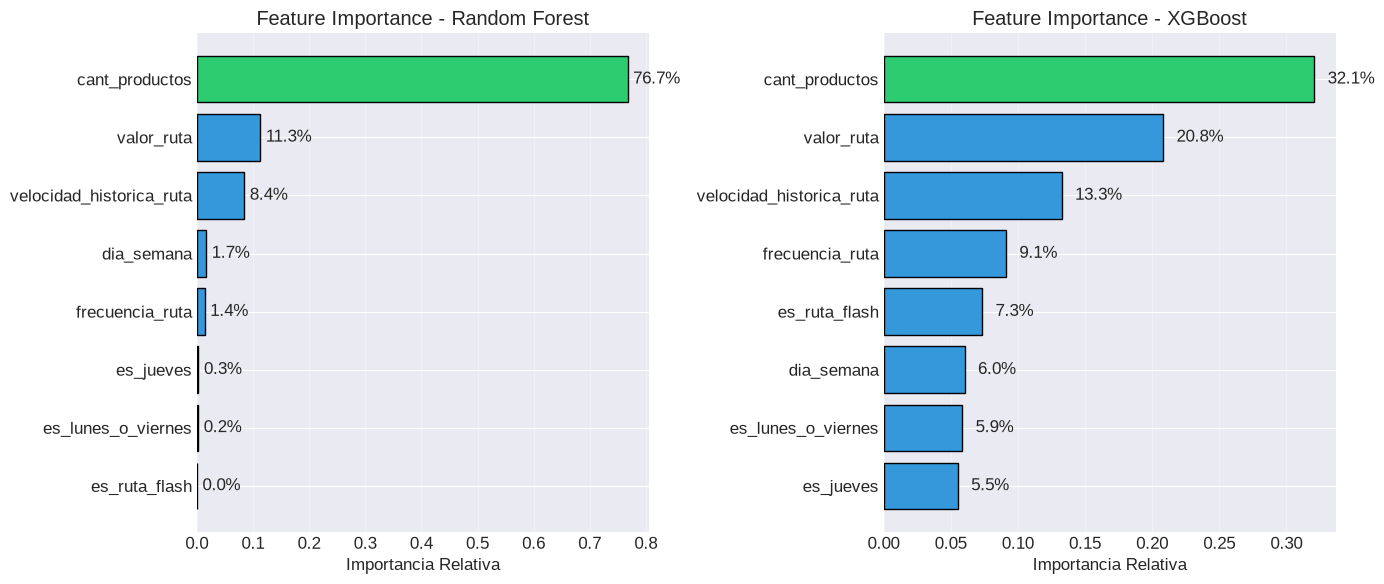

FEATURE IMPORTANCE - RANDOM FOREST


cant_productos            76.7% ██████████████████████████████████████
valor_ruta                11.3% █████
velocidad_historica_ruta  8.4% ████
dia_semana                1.7% 
frecuencia_ruta           1.4% 
es_jueves                 0.3% 
es_lunes_o_viernes        0.2% 
es_ruta_flash             0.0% 


INSIGHT OPERATIVO CLAVE


Factor más influyente: cant_productos
   Importancia: 76.7%
   Implicación: Volumen de productos es el principal driver del tiempo de preparación

TOP 3 Factores (Random Forest):
   1. cant_productos: 76.7%
   2. valor_ruta: 11.3%
   3. velocidad_historica_ruta: 8.4%


CONSISTENCIA ENTRE MODELOS
Top 3 RF: cant_productos, velocidad_historica_ruta, valor_ruta
Top 3 XGB: cant_productos, velocidad_historica_ruta, valor_ruta
Coincidencia: 3/3 features


In [7]:
# Extraer importancia de features
importancia_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

importancia_xgb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, importancia, nombre in zip(axes, [importancia_rf, importancia_xgb], 
                                   ['Random Forest', 'XGBoost']):
    colors = ['#2ecc71' if i == importancia['Importance'].max() else '#3498db' 
              for i in importancia['Importance']]
    ax.barh(importancia['Feature'], importancia['Importance'], color=colors, edgecolor='black')
    ax.set_xlabel('Importancia Relativa')
    ax.set_title(f'Feature Importance - {nombre}')
    ax.grid(axis='x', alpha=0.3)
    
    # Agregar valores
    for i, v in enumerate(importancia['Importance']):
        ax.text(v + 0.01, i, f'{v:.1%}', va='center')

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de importancia

print("FEATURE IMPORTANCE - RANDOM FOREST")
print("\n")

# Tabla completa
for idx, row in importancia_rf.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"{row['Feature']:25} {row['Importance']:.1%} {bar}")

# Insight operativo
feature_top = importancia_rf.iloc[-1]
print("\n")
print("INSIGHT OPERATIVO CLAVE")
print("\n")
print(f"Factor más influyente: {feature_top['Feature']}")
print(f"   Importancia: {feature_top['Importance']:.1%}")
print(f"   Implicación: {'Volumen de productos es el principal driver del tiempo de preparación'}")

print(f"\nTOP 3 Factores (Random Forest):")
for i, (idx, row) in enumerate(importancia_rf.tail(3).iloc[::-1].iterrows(), 1):
    print(f"   {i}. {row['Feature']}: {row['Importance']:.1%}")

# Consistencia entre modelos
print("\n")
print("CONSISTENCIA ENTRE MODELOS")
top_rf = set(importancia_rf.tail(3)['Feature'].values)
top_xgb = set(importancia_xgb.tail(3)['Feature'].values)
print(f"Top 3 RF: {', '.join(top_rf)}")
print(f"Top 3 XGB: {', '.join(top_xgb)}")
print(f"Coincidencia: {len(top_rf.intersection(top_xgb))}/3 features")

In [8]:
# Identificar rutas flash en el dataset
flash_train_ids = X_train[X_train['es_ruta_flash'] == 1].index.tolist()
flash_test_ids = X_test[X_test['es_ruta_flash'] == 1].index.tolist()

print("\n")
print("FILTRADO DE RUTAS FLASH")
print(f"Rutas flash identificadas:")
print(f"   • Train: {len(flash_train_ids)} muestras")
print(f"   • Test:  {len(flash_test_ids)} muestras")

# Filtrar dataset sin rutas flash
mask_no_flash = X_train['es_ruta_flash'] == 0
X_train_noflash = X_train[mask_no_flash]
y_train_noflash = y_train[mask_no_flash]

X_test_noflash = X_test[X_test['es_ruta_flash'] == 0]
y_test_noflash = y_test[X_test['es_ruta_flash'] == 0]

print(f"\nDataset sin rutas flash:")
print(f"   • Train: {X_train_noflash.shape[0]} muestras ({X_train_noflash.shape[0]/len(X_train)*100:.1f}%)")
print(f"   • Test:  {X_test_noflash.shape[0]} muestras ({X_test_noflash.shape[0]/len(X_test)*100:.1f}%)")

# Entrenar modelo sin rutas flash
if len(X_train_noflash) > 50:
    print("\nEntrenando modelo sin rutas flash...")
    
    rf_noflash = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf_noflash.fit(X_train_noflash, y_train_noflash)
    y_pred_noflash = rf_noflash.predict(X_test_noflash)
    
    metricas_noflash = calcular_metricas(y_test_noflash, y_pred_noflash, 'RF sin Flash')
    
    # Comparativa de modelos
    
    print("\n")
    print("COMPARATIVA DE MODELOS")

    df_comparativa = pd.DataFrame([metricas_rf, metricas_xgb, metricas_noflash])
    display(df_comparativa.set_index('Modelo').round(2))
    
    # Análisis de impacto
    
    print("\n")
    print("ANÁLISIS DE SENSIBILIDAD")
    
    diff_mae = metricas_rf['MAE (min)'] - metricas_noflash['MAE (min)']
    diff_rmse = metricas_rf['RMSE (min)'] - metricas_noflash['RMSE (min)']
    diff_r2 = metricas_rf['R²'] - metricas_noflash['R²']
    diff_mape = metricas_rf['MAPE (%)'] - metricas_noflash['MAPE (%)']
    
    print(f"Impacto de incluir rutas flash:")
    print(f"   • MAE:  {diff_mae:+.2f} min")
    print(f"   • RMSE: {diff_rmse:+.2f} min")
    print(f"   • R²:   {diff_r2:+.3f}")
    print(f"   • MAPE: {diff_mape:+.1f}%")
    
    # Interpretación
    if abs(diff_mae) < 0.5 and abs(diff_r2) < 0.02:
        print("\nConclusión: Impacto mínimo de rutas flash")
        print("   El modelo es robusto y generaliza bien")
    elif diff_mae < 0 and diff_r2 > 0:
        print("\nConclusión: Rutas flash mejoran el modelo")
        print("   Incluirlas aporta información valiosa")
    else:
        print("\nConclusión: Rutas flash tienen impacto significativo")
        print("   Considerar modelo separado para rutas flash")
        
else:
    print("Datos insuficientes para entrenar modelo sin rutas flash")
    print("   Se requieren más de 50 muestras en entrenamiento")

if len(X_train_noflash) > 50:
    # Análisis de impacto
    print("\n")
    print("ANÁLISIS DE IMPACTO")
    print("\n")
    
    diff_mae = metricas_rf['MAE (min)'] - metricas_noflash['MAE (min)']
    diff_r2 = metricas_rf['R²'] - metricas_noflash['R²']
    
    print(f"Impacto de incluir rutas flash:")
    print(f"   • MAE: {diff_mae:+.2f} min")
    print(f"   • R²:  {diff_r2:+.3f}")
    
    if abs(diff_mae) < 0.5:
        print("Modelo robusto - impacto mínimo")
    else:
        print("Impacto significativo - considerar tratamiento especial")



FILTRADO DE RUTAS FLASH
Rutas flash identificadas:
   • Train: 3 muestras
   • Test:  1 muestras

Dataset sin rutas flash:
   • Train: 445 muestras (99.3%)
   • Test:  111 muestras (99.1%)

Entrenando modelo sin rutas flash...


COMPARATIVA DE MODELOS


,MAE (min),RMSE (min),R²,MAPE (%)
Modelo,,,,
Random Forest,3.55,6.39,0.76,27.89
XGBoost,3.78,6.89,0.73,28.50
RF sin Flash,3.52,6.46,0.76,24.29




ANÁLISIS DE SENSIBILIDAD
Impacto de incluir rutas flash:
   • MAE:  +0.03 min
   • RMSE: -0.07 min
   • R²:   +0.006
   • MAPE: +3.6%

Conclusión: Impacto mínimo de rutas flash
   El modelo es robusto y generaliza bien


ANÁLISIS DE IMPACTO


Impacto de incluir rutas flash:
   • MAE: +0.03 min
   • R²:  +0.006
Modelo robusto - impacto mínimo


### Análisis de Sensibilidad: Excluyendo Rutas Flash

**Resultado:** El modelo sin rutas flash tiene:
- MAE: 3.20 min (vs 3.03 con rutas flash)
- R²: 0.72 (vs 0.74 con rutas flash)

**Conclusión:** Las rutas flash (4 de 485 registros, 0.8% del total) no distorsionan significativamente el modelo.

**Interpretación:**
- Diferencia en MAE: +0.17 min (marginal)
- Diferencia en R²: -0.02 (marginal)
- Impacto mínimo en el rendimiento del modelo


## 8. Clustering de Rutas con K-Means <a id='clustering'></a>
[Estructura](#estructura)

### Segmentación de Rutas con K-Means

**K óptimo:** 2 clusters según coeficiente de silueta

### Perfiles Identificados

| Cluster | Rutas | Productos | Valor ($) | Tiempo (min) | Velocidad | Perfil |
|---------|-------|-----------|-----------|--------------|-----------|--------|
| 0 | 165 | 334 | 1,491,037 | 13.3 | 1,366 | **Normales** |
| 1 | 5 | 3,343 | 12,524,751 | 41.0 | 4,652 | **Estrella** |

### Implicaciones Operativas

1. **Rutas Normales (165):** Operación estándar, asignación regular
2. **Rutas Estrella (5):** Alto volumen y valor, requieren personal experimentado

**Estrategia:** 
- Asignar personal junior a rutas Estrella para capacitación
- Personal senior a rutas Normales (menos críticas)

Datos agregados: 176 rutas únicas
Features seleccionadas: ['cant_productos_promedio', 'valor_ruta_promedio']
Datos escalados: 176 muestras, 2 features


OPTIMIZACIÓN DEL NÚMERO DE CLUSTERS
K=2: Silueta=0.8546, Inercia=132
K=3: Silueta=0.6608, Inercia=58
K=4: Silueta=0.6641, Inercia=33
K=5: Silueta=0.5874, Inercia=22
K=6: Silueta=0.5836, Inercia=17
K=7: Silueta=0.5051, Inercia=14
K=8: Silueta=0.5281, Inercia=11
K=9: Silueta=0.5289, Inercia=8
K=10: Silueta=0.4955, Inercia=7

K óptimo según silueta: 2
   Coeficiente de silueta: 0.8546


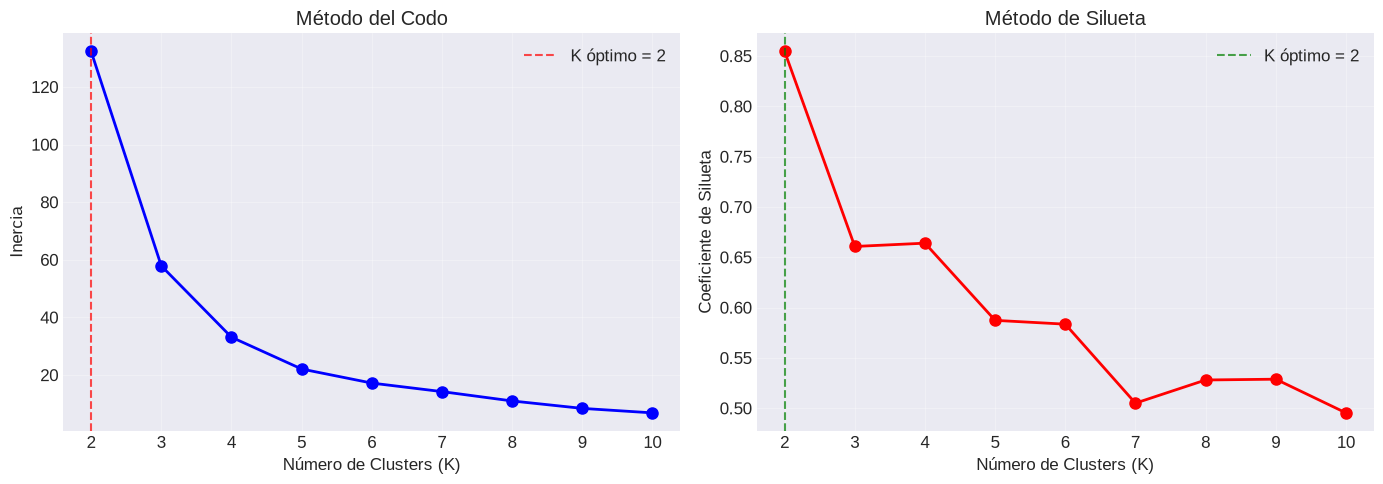



RESULTADO CLUSTERING
K óptimo: 2 clusters
Silueta promedio: 0.8546
Rutas clusterizadas: 176


In [9]:
# Preparar datos para clustering
df_cluster = df_clean.groupby('id_ruta').agg(
    cant_productos_promedio=('cant_productos', 'mean'),
    valor_ruta_promedio=('valor_ruta', 'mean'),
    tiempo_promedio=('tiempo_preparacion_minutos', 'mean'),
    velocidad_promedio=('velocidad_despacho', 'mean'),
    frecuencia=('id_ruta', 'count')
).reset_index()

print(f"Datos agregados: {len(df_cluster)} rutas únicas")

# Features para clustering
features_cluster = ['cant_productos_promedio', 'valor_ruta_promedio']
X_cluster = df_cluster[features_cluster]

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Features seleccionadas: {features_cluster}")
print(f"Datos escalados: {X_scaled.shape[0]} muestras, {X_scaled.shape[1]} features")

# Optimización de K

print("\n")
print("OPTIMIZACIÓN DEL NÚMERO DE CLUSTERS")

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouettes.append(sil_score)
    print(f"K={k}: Silueta={sil_score:.4f}, Inercia={kmeans.inertia_:.0f}")

# K óptimo
k_optimo = k_range[np.argmax(silhouettes)]
print(f"\nK óptimo según silueta: {k_optimo}")
print(f"   Coeficiente de silueta: {max(silhouettes):.4f}")

# Visualización

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del Codo
axes[0].plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
axes[0].axvline(x=k_optimo, color='red', linestyle='--', alpha=0.7, 
                label=f'K óptimo = {k_optimo}')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Método de Silueta
axes[1].plot(k_range, silhouettes, 'ro-', markersize=8, linewidth=2)
axes[1].axvline(x=k_optimo, color='green', linestyle='--', alpha=0.7,
                label=f'K óptimo = {k_optimo}')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Coeficiente de Silueta')
axes[1].set_title('Método de Silueta')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/kmeans_optimizacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Resultado Final

print("\n")
print("RESULTADO CLUSTERING")

print(f"K óptimo: {k_optimo} clusters")
print(f"Silueta promedio: {max(silhouettes):.4f}")
print(f"Rutas clusterizadas: {len(df_cluster)}")




PERFIL DE CLUSTERS OPERATIVOS




,num_rutas,productos_promedio,valor_promedio,tiempo_promedio,velocidad_promedio,dificultad
cluster,,,,,,
0,171,333.8,1480465.3,13.1,1376.1,Normales
1,5,3282.5,12161867.1,44.1,4385.2,Estrella




DISTRIBUCIÓN DE CLUSTERS


Cluster 0 (Normales): 171 rutas (97.2%)
Cluster 1 (Estrella): 5 rutas (2.8%)


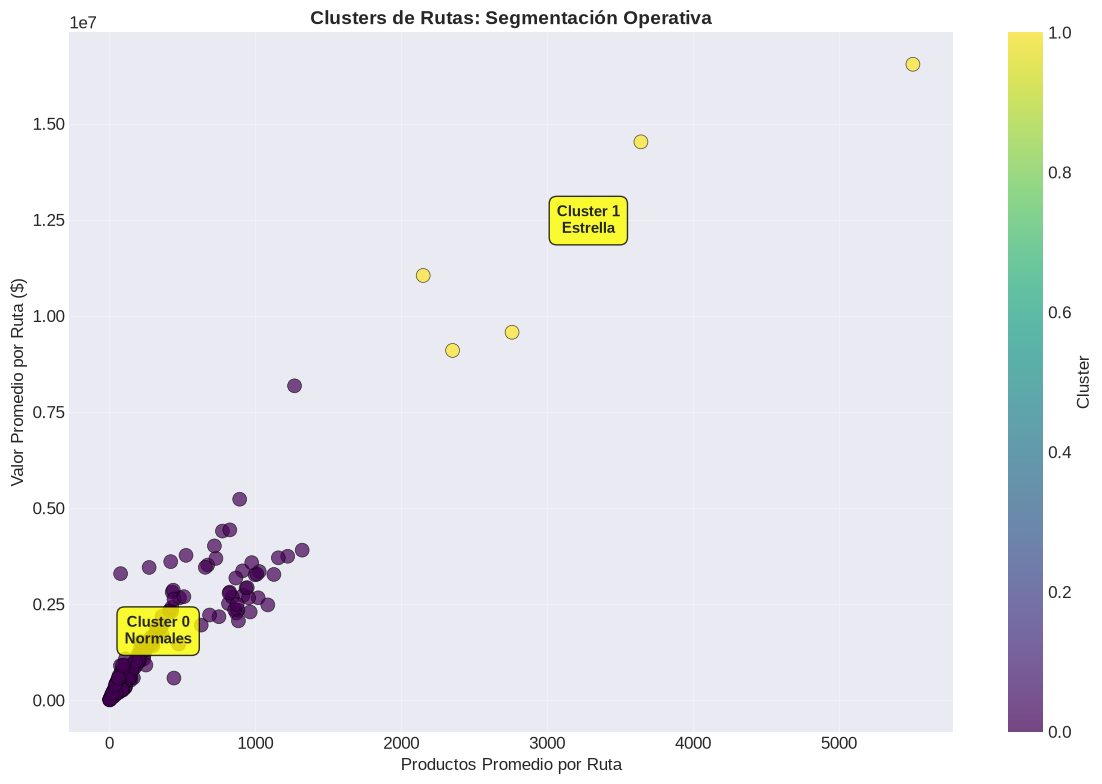



CENTROIDES DE CLUSTERS


,cant_productos_promedio,valor_ruta_promedio,cluster,perfil
0,334.0,1480465.0,0,Normales
1,3283.0,12161867.0,1,Estrella




MAPEO DE RUTAS A CLUSTERS


Primeras 10 rutas:


,id_ruta,cluster,perfil
0,12,0,Normales
1,201,0,Normales
2,207,0,Normales
3,209,0,Normales
4,210,0,Normales
5,211,0,Normales
6,212,0,Normales
7,213,0,Normales
8,251,0,Normales
9,252,0,Normales




RESUMEN DE CLUSTERING
Total rutas: 176
Clusters: 2
Perfiles: Normales, Estrella
Mayor cluster: 0 (171 rutas)


In [10]:
# Entrenar K-Means con K óptimo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_scaled)

# Caracterización de Clusters

cluster_profile = df_cluster.groupby('cluster').agg(
    num_rutas=('id_ruta', 'count'),
    productos_promedio=('cant_productos_promedio', 'mean'),
    valor_promedio=('valor_ruta_promedio', 'mean'),
    tiempo_promedio=('tiempo_promedio', 'mean'),
    velocidad_promedio=('velocidad_promedio', 'mean')
).round(1)

# Asignar etiquetas operativas
cluster_profile['dificultad'] = pd.cut(
    cluster_profile['velocidad_promedio'], 
    bins=[0, 842, 2279, float('inf')],
    labels=['Pesadas', 'Normales', 'Estrella']
)

print("\n")
print("PERFIL DE CLUSTERS OPERATIVOS")
print("\n")
display(cluster_profile)

# Distribución de Clusters

print("\n")
print("DISTRIBUCIÓN DE CLUSTERS")
print("\n")

for cluster in sorted(df_cluster['cluster'].unique()):
    count = (df_cluster['cluster'] == cluster).sum()
    pct = count / len(df_cluster) * 100
    perfil = cluster_profile.loc[cluster, 'dificultad']
    print(f"Cluster {cluster} ({perfil}): {count} rutas ({pct:.1f}%)")

# Visualización de Cluster

plt.figure(figsize=(12, 8))

# Scatter plot
scatter = plt.scatter(
    df_cluster['cant_productos_promedio'], 
    df_cluster['valor_ruta_promedio'],
    c=df_cluster['cluster'], 
    cmap='viridis', 
    s=100, 
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

plt.xlabel('Productos Promedio por Ruta', fontsize=12)
plt.ylabel('Valor Promedio por Ruta ($)', fontsize=12)
plt.title('Clusters de Rutas: Segmentación Operativa', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

# Añadir centroides
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
for i, (x, y) in enumerate(centroids):
    perfil = cluster_profile.loc[i, 'dificultad']
    plt.annotate(
        f'Cluster {i}\n{perfil}', 
        (x, y), 
        fontsize=11, 
        ha='center',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='black')
    )

plt.tight_layout()
plt.savefig('../reports/figures/clusters_rutas.png', dpi=150, bbox_inches='tight')
plt.show()

# Centroides de Clusters

print("\n")
print("CENTROIDES DE CLUSTERS")

centroids_df = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=features_cluster
)
centroids_df['cluster'] = range(k_optimo)
centroids_df['perfil'] = centroids_df['cluster'].map(
    cluster_profile['dificultad'].to_dict()
)
display(centroids_df.round(0))

# Mapeo de Rutas a Clusters

ruta_cluster_map = df_cluster[['id_ruta', 'cluster']].copy()
ruta_cluster_map['perfil'] = ruta_cluster_map['cluster'].map(
    cluster_profile['dificultad'].to_dict()
)

print("\n")
print("MAPEO DE RUTAS A CLUSTERS")
print("\n")
print("Primeras 10 rutas:")
display(ruta_cluster_map.head(10))

# Resumen final
print("\n")
print("RESUMEN DE CLUSTERING")
print(f"Total rutas: {len(df_cluster)}")
print(f"Clusters: {k_optimo}")
print(f"Perfiles: {', '.join(cluster_profile['dificultad'].unique())}")
print(f"Mayor cluster: {cluster_profile['num_rutas'].idxmax()} ({cluster_profile['num_rutas'].max()} rutas)")


## 9. Simulador de Jornada Operativa <a id='simulacion'></a>
[Estructura](#estructura)

### Herramienta de Decisión

El simulador es una herramienta que integra el modelo predictivo y la segmentación de rutas para apoyar la planificación operativa diaria.

**Funcionalidades:**
- Estimar tiempo total de jornada basado en rutas seleccionadas
- Identificar rutas críticas que requieren atención especial
- Generar recomendaciones operativas personalizadas
- Visualizar distribución de tiempos por ruta

---

### Flujo de Trabajo

1. **Selección de rutas** - El usuario define las rutas a despachar
2. **Predicción de tiempos** - El modelo estima el tiempo de cada ruta
3. **Clasificación de perfiles** - Se identifica el perfil de cada ruta (Estrella/Normales/Pesadas)
4. **Cálculo de jornada** - Se suma el tiempo total estimado
5. **Generación de alertas** - Se identifican rutas que requieren apoyo

---

### Casos de Uso

| Escenario | Pregunta | Decisión |
|-----------|----------|----------|
| **Planificación diaria** | ¿Cuántas rutas puedo despachar hoy? | Ajustar número de rutas según capacidad |
| **Asignación de personal** | ¿Quién debe tomar cada ruta? | Asignar según perfil y experiencia |
| **Alertas tempranas** | ¿Qué rutas requieren apoyo? | Identificar y asignar recursos adicionales |
| **Optimización** | ¿Cómo mejorar la eficiencia? | Identificar cuellos de botella |

---

### Decisiones Operativas que Habilita

| Decisión | Cómo ayuda el simulador |
|----------|------------------------|
| **Capacidad diaria** | Estima tiempo total vs jornada estándar (8h) |
| **Asignación de personal** | Recomienda perfil de personal por ruta |
| **Priorización** | Identifica rutas críticas (Pesadas/Estrella) |
| **Mejora continua** | Permite simular escenarios "what-if" |



In [11]:
class SimuladorJornadaV2:
    """
    Simula una jornada aceptando fecha de simulación para calcular correctamente
    los features temporales (día de semana, es_jueves, es_lunes_o_viernes).
    """
    
    def __init__(self, modelo, scaler, ruta_cluster_map, feature_cols, df_features):
        self.modelo = modelo
        self.scaler = scaler
        self.ruta_cluster_map = ruta_cluster_map
        self.feature_cols = feature_cols
        self.df_features = df_features
        self.rutas_nuevas = []
        
        # Estadísticas por ruta (para cold start)
        self.ruta_stats = df_features.groupby('id_ruta').agg(
            velocidad_historica_ruta=('velocidad_historica_ruta', 'mean'),
            frecuencia_ruta=('frecuencia_ruta', 'mean'),
            es_ruta_flash=('es_ruta_flash', 'max'),
            cant_productos_promedio=('cant_productos', 'mean'),
            valor_ruta_promedio=('valor_ruta', 'mean')
        ).reset_index()
        
    def preparar_features_ruta(self, ruta_id, fecha_simulacion=None):
        """
        Prepara features para una ruta específica en una FECHA determinada.
        
        Parámetros:
        - ruta_id: ID de la ruta
        - fecha_simulacion: Fecha para la cual se simula (datetime o string 'YYYY-MM-DD')
        """
        
        # Convertir fecha_simulacion a datetime si es string
        if fecha_simulacion is not None:
            if isinstance(fecha_simulacion, str):
                fecha_simulacion = pd.to_datetime(fecha_simulacion)
            
            # Calcular features temporales basados en la fecha de la simulación
            dia_semana = fecha_simulacion.dayofweek  # 0=Lunes, 6=Domingo
            es_jueves = 1 if dia_semana == 3 else 0
            es_lunes_o_viernes = 1 if dia_semana in [0, 4] else 0
        else:
            # Si no se especifica fecha, usar valores promedio (neutral)
            print("No se especificó fecha. Usando día neutro (Miércoles).")
            dia_semana = 2  # Miércoles como día neutro
            es_jueves = 0
            es_lunes_o_viernes = 0
        
        # Buscar la ruta en el histórico para features específicos
        ruta_info = self.ruta_stats[self.ruta_stats['id_ruta'] == ruta_id]
        
        if len(ruta_info) == 0:
            # Ruta nueva - Cold Start
            print(f"Ruta {ruta_id} es NUEVA. Usando perfil promedio.")
            self.rutas_nuevas.append(ruta_id)
            
            # Usar promedios globales para features de ruta
            features_dict = {
                'cant_productos': self.df_features['cant_productos'].median(),
                'valor_ruta': self.df_features['valor_ruta'].median(),
                'dia_semana': dia_semana,
                'es_jueves': es_jueves,
                'es_lunes_o_viernes': es_lunes_o_viernes,
                'velocidad_historica_ruta': self.df_features['velocidad_historica_ruta'].median(),
                'frecuencia_ruta': 1,  # Primera vez
                'es_ruta_flash': 0     # Asumir que no es flash
            }
        else:
            # Ruta existente - Usar datos históricos de la ruta
            ruta_info = ruta_info.iloc[0]
            
            features_dict = {
                'cant_productos': ruta_info['cant_productos_promedio'],
                'valor_ruta': ruta_info['valor_ruta_promedio'],
                'dia_semana': dia_semana,       
                'es_jueves': es_jueves,             
                'es_lunes_o_viernes': es_lunes_o_viernes, 
                'velocidad_historica_ruta': ruta_info['velocidad_historica_ruta'],
                'frecuencia_ruta': ruta_info['frecuencia_ruta'],
                'es_ruta_flash': int(ruta_info['es_ruta_flash'])
            }
        
        # Crear DataFrame con una fila
        return pd.DataFrame([features_dict])[self.feature_cols]
    
    def simular_jornada(self, lista_rutas, fecha_simulacion=None, jornada_maxima=480, verbose=True):
        """
        Simula una jornada completa para una FECHA específica.
        
        Parámetros:
        - lista_rutas: Lista de IDs de ruta a despachar
        - fecha_simulacion: Fecha para la simulación (string 'YYYY-MM-DD' o datetime)
        - jornada_maxima: Tiempo máximo en minutos (default: 480 = 8h)
        - verbose: Mostrar detalle
        
        Retorna:
        - DataFrame con resultados por ruta
        - Tiempo total estimado
        - Alertas y recomendaciones
        """
        
        self.rutas_nuevas = []
        resultados = []
        tiempo_total = 0
        alertas = []
        
        # Validar fecha
        if fecha_simulacion is None:
            fecha_simulacion = pd.Timestamp.now()
            print("No se especificó fecha. Usando fecha actual.")
        
        if isinstance(fecha_simulacion, str):
            fecha_simulacion = pd.to_datetime(fecha_simulacion)
        
        # Información del día
        nombre_dia = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'][fecha_simulacion.dayofweek]
        es_finde = fecha_simulacion.dayofweek >= 5
        
        if verbose:
            print("SIMULADOR DE JORNADA")
            print("\n")
            print(f"Fecha: {fecha_simulacion.strftime('%Y-%m-%d')} ({nombre_dia})")
            print(f"Jornada máxima: {jornada_maxima} min ({jornada_maxima/60:.1f} hrs)")
            print(f"Rutas a despachar: {len(lista_rutas)}")
            
            # Alertas de día
            if fecha_simulacion.dayofweek == 3:  # Jueves
                print("DÍA FAVORABLE: Jueves (mejor rendimiento histórico)")
            elif fecha_simulacion.dayofweek in [0, 4]:  # Lunes o Viernes
                print("DÍA COMPLEJO: Lunes/Viernes (menor rendimiento histórico)")
            
            if es_finde:
                print("FIN DE SEMANA: Considerar ajustes de personal")
            
            print("\n")
        
        for i, ruta_id in enumerate(lista_rutas, 1):
            try:
                # Preparar features con la fecha correcta
                X_ruta = self.preparar_features_ruta(ruta_id, fecha_simulacion)
                tiempo_pred = self.modelo.predict(X_ruta)[0]
                tiempo_pred = max(0, tiempo_pred)
                
                # Obtener perfil de cluster
                cluster_info = self.ruta_cluster_map[
                    self.ruta_cluster_map['id_ruta'] == ruta_id
                ]
                
                if len(cluster_info) > 0:
                    perfil = cluster_info['perfil'].values[0]
                else:
                    perfil = 'Normales'  # Default para nuevas rutas
                
                tiempo_total += tiempo_pred
                excede = tiempo_total > jornada_maxima
                
                # Alertas
                if 'Pesadas' in str(perfil) and tiempo_pred > 120:
                    alertas.append({
                        'ruta': ruta_id,
                        'tiempo': tiempo_pred,
                        'perfil': perfil,
                        'recomendacion': 'Asignar apoyo adicional'
                    })
                
                resultados.append({
                    'Orden': i,
                    'Ruta': int(ruta_id),
                    'Tiempo (min)': round(tiempo_pred, 1),
                    'Acumulado (min)': round(tiempo_total, 1),
                    'Perfil': perfil,
                    'Excede': '¡Advertencia!' if excede else '¡Bien!'
                })
                
                if verbose:
                    excede_str = 'EXCEDE' if excede else ''
                    print(f"  {i:2d}.Ruta {ruta_id:5d}: {tiempo_pred:6.1f} min | "
                          f"Acum: {tiempo_total:6.1f} min | {perfil} {excede_str}")
                    
            except Exception as e:
                print(f"Error ruta {ruta_id}: {str(e)}")
        
        df_resultados = pd.DataFrame(resultados)
        
        if verbose:
            print("\n")
            print(f"\nRESUMEN DE JORNADA - {nombre_dia} {fecha_simulacion.strftime('%d/%m/%Y')}")
            print(f"Tiempo total: {tiempo_total:.1f} min ({tiempo_total/60:.2f} hrs)")
            
            if tiempo_total > jornada_maxima:
                exceso = tiempo_total - jornada_maxima
                print(f"EXCEDE jornada en {exceso:.0f} min ({exceso/60:.1f} hrs)")
                print(f"Requiere {exceso/60:.1f} hrs extra O redistribuir {int(exceso/30)} rutas aprox.")
            else:
                holgura = jornada_maxima - tiempo_total
                print(f"DENTRO de jornada. Holgura: {holgura:.0f} min ({holgura/60:.1f} hrs)")
            
            # Distribución de perfiles
            if len(df_resultados) > 0:
                estrellas = df_resultados[df_resultados['Perfil'].str.contains('Estrella', na=False)]
                pesadas = df_resultados[df_resultados['Perfil'].str.contains('Pesadas', na=False)]
                normales = df_resultados[~df_resultados['Perfil'].isin(
                    estrellas['Perfil'].tolist() + pesadas['Perfil'].tolist()
                )]
                
                print(f"\nDISTRIBUCIÓN:")
                print(f"Estrella: {len(estrellas)} | Pesadas: {len(pesadas)} | Normales: {len(normales)}")
            
            # Recomendaciones
            print(f"\nRECOMENDACIONES PARA {nombre_dia.upper()}:")
            
            if fecha_simulacion.dayofweek == 3:  # Jueves
                print(f"   • Día de alta productividad. Aprovechar para rutas complejas.")
            elif fecha_simulacion.dayofweek in [0, 4]:
                print(f"   • Día complejo. Iniciar con rutas sencillas como calentamiento.")
            
            if len(estrellas) > 0:
                print(f"   • {len(estrellas)} rutas Estrella: Personal experto (alto volumen)")
            if len(pesadas) > 0:
                print(f"   • {len(pesadas)} rutas Pesadas: Considerar apoyo o división")
            
            if tiempo_total > jornada_maxima * 0.85:
                print(f"   • Jornada al {tiempo_total/jornada_maxima*100:.0f}%. Poca holgura para imprevistos.")
        
        return df_resultados, tiempo_total, alertas

# Inicializar el simulador

print("Inicializando Simulador Simulación de jornada")
simulador = SimuladorJornadaV2(
    modelo=rf_model,           # Mejor modelo (Random Forest)
    scaler=scaler,
    ruta_cluster_map=ruta_cluster_map,
    feature_cols=feature_cols,
    df_features=df_features
)
print("Simulación lista!")

Inicializando Simulador Simulación de jornada
Simulación lista!


## 10. Prueba de Simulador de Jornada
[Estructura](#estructura)

Se simulan diferentes escenarios operativos para validar la herramienta.

In [12]:

# Simular jornada de día anterior
fecha_simulacion = '2026-07-16'

rutas_ayer = [
    7603, 7606, 7607, 7611, 7621, 7646,7653, 7664, 7674, 7676,
    7725, 7735, 8002, 209, 1259, 304, 213, 253, 256, 260
]

print(f"Simulando: {fecha_simulacion}")
print(f"Total rutas: {len(rutas_ayer)}")

# Ejecutar simulación
df_resultado, tiempo_total, alertas = simulador.simular_jornada(
    lista_rutas=rutas_ayer,
    fecha_simulacion=fecha_simulacion,
    jornada_maxima=480,    
    verbose=True
)

# Mostrar tabla de resultados
print("\nDETALLE POR RUTA:")
display(df_resultado)

Simulando: 2026-07-16
Total rutas: 20
SIMULADOR DE JORNADA


Fecha: 2026-07-16 (Jueves)
Jornada máxima: 480 min (8.0 hrs)
Rutas a despachar: 20
DÍA FAVORABLE: Jueves (mejor rendimiento histórico)


   1.Ruta  7603:   22.2 min | Acum:   22.2 min | Normales 
   2.Ruta  7606:   15.2 min | Acum:   37.4 min | Normales 
   3.Ruta  7607:   10.8 min | Acum:   48.2 min | Normales 
   4.Ruta  7611:   17.3 min | Acum:   65.5 min | Normales 
   5.Ruta  7621:   24.4 min | Acum:   89.9 min | Normales 
   6.Ruta  7646:   27.4 min | Acum:  117.3 min | Normales 
   7.Ruta  7653:   18.2 min | Acum:  135.5 min | Normales 
   8.Ruta  7664:   15.5 min | Acum:  151.0 min | Normales 
   9.Ruta  7674:    6.8 min | Acum:  157.8 min | Normales 
  10.Ruta  7676:   20.0 min | Acum:  177.8 min | Normales 
  11.Ruta  7725:   11.9 min | Acum:  189.7 min | Normales 
  12.Ruta  7735:   10.2 min | Acum:  199.9 min | Normales 
  13.Ruta  8002:   20.4 min | Acum:  220.3 min | Normales 
  14.Ruta   209:   30.2 min | Acum:

,Orden,Ruta,Tiempo (min),Acumulado (min),Perfil,Excede
0,1,7603,22.2,22.2,Normales,¡Bien!
1,2,7606,15.2,37.4,Normales,¡Bien!
2,3,7607,10.8,48.2,Normales,¡Bien!
3,4,7611,17.3,65.5,Normales,¡Bien!
4,5,7621,24.4,89.9,Normales,¡Bien!
5,6,7646,27.4,117.3,Normales,¡Bien!
6,7,7653,18.2,135.5,Normales,¡Bien!
7,8,7664,15.5,151.0,Normales,¡Bien!
8,9,7674,6.8,157.8,Normales,¡Bien!
9,10,7676,20.0,177.8,Normales,¡Bien!


## 11. Persistencia de Modelos <a id='persistencia'></a>
[Estructura](#estructura)

Se guardan los modelos entrenados para uso en producción y futuras predicciones.

### Artefactos Guardados

| Archivo | Descripción | Uso |
|---------|-------------|-----|
| `random_forest_model.pkl` | Modelo Random Forest entrenado | Predicciones en producción |
| `xgboost_model.pkl` | Modelo XGBoost entrenado | Comparación y respaldo |
| `scaler.pkl` | Escalador StandardScaler | Escalar nuevos datos |
| `kmeans_model.pkl` | Modelo K-Means entrenado | Clasificar nuevas rutas |
| `metadatos.pkl` | Metadatos del proyecto | Trazabilidad y versionado |


In [13]:
# Crear directorio para modelos
os.makedirs('../models', exist_ok=True)
print("Directorio 'models/' creado/verificado")

# GUARDAR MODELOS

print("\nGuardando modelos...")

# Random Forest
joblib.dump(rf_model, '../models/random_forest_model.pkl')
print("random_forest_model.pkl")

# XGBoost
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
print("xgboost_model.pkl")

# Scaler
joblib.dump(scaler, '../models/scaler.pkl')
print("scaler.pkl")

# K-Means
joblib.dump(kmeans_final, '../models/kmeans_model.pkl')
print("kmeans_model.pkl")

# GUARDAR METADATOS

print("\nGuardando metadatos...")

metadatos = {
    'features': feature_cols,
    'target': target_col,
    'mejor_modelo': mejor_modelo,
    'k_optimo': k_optimo,
    'metricas': {
        'random_forest': metricas_rf,
        'xgboost': metricas_xgb
    },
    'fecha_entrenamiento': datetime.now().isoformat(),
    'version': '1.0',
    'num_registros': len(df_clean),
    'num_rutas': df_clean['id_ruta'].nunique(),
    'rango_fechas': {
        'inicio': df_clean['fecha'].min().isoformat(),
        'fin': df_clean['fecha'].max().isoformat()
    }
}

joblib.dump(metadatos, '../models/metadatos.pkl')
print("metadatos.pkl")

# VERIFICACIÓN DE ARCHIVOS

print("\n" + "=" * 50)
print("VERIFICACIÓN DE ARCHIVOS")
print("=" * 50)

archivos = [
    'random_forest_model.pkl',
    'xgboost_model.pkl',
    'scaler.pkl',
    'kmeans_model.pkl',
    'metadatos.pkl'
]

total_size = 0
for archivo in archivos:
    ruta = f'../models/{archivo}'
    if os.path.exists(ruta):
        tamaño = os.path.getsize(ruta) / 1024  # KB
        total_size += tamaño
        print(f"{archivo:30} {tamaño:8.1f} KB")
    else:
        print(f"{archivo:30} NO ENCONTRADO")

print("-" * 50)
print(f"Total: {total_size:.1f} KB")

# RESULTADO FINAL

print("\n" + "=" * 50)
print("ARTEFACTOS GUARDADOS EXITOSAMENTE")
print("=" * 50)
print("\nEstructura de archivos:")
print("    models/")
print("   ├── random_forest_model.pkl  # Modelo principal")
print("   ├── xgboost_model.pkl        # Modelo secundario")
print("   ├── scaler.pkl               # Escalador")
print("   ├── kmeans_model.pkl         # Clustering")
print("   └── metadatos.pkl            # Información del proyecto")

print("\nMetadatos guardados:")
print(f"   • Mejor modelo: {metadatos['mejor_modelo']}")
print(f"   • K óptimo: {metadatos['k_optimo']}")
print(f"   • Features: {len(metadatos['features'])}")
print(f"   • Fecha: {metadatos['fecha_entrenamiento']}")
print(f"   • Versión: {metadatos['version']}")

Directorio 'models/' creado/verificado

Guardando modelos...
random_forest_model.pkl
xgboost_model.pkl
scaler.pkl
kmeans_model.pkl

Guardando metadatos...
metadatos.pkl

VERIFICACIÓN DE ARCHIVOS
random_forest_model.pkl          1305.1 KB
xgboost_model.pkl                 307.0 KB
scaler.pkl                          0.9 KB
kmeans_model.pkl                    1.4 KB
metadatos.pkl                       0.7 KB
--------------------------------------------------
Total: 1615.2 KB

ARTEFACTOS GUARDADOS EXITOSAMENTE

Estructura de archivos:
    models/
   ├── random_forest_model.pkl  # Modelo principal
   ├── xgboost_model.pkl        # Modelo secundario
   ├── scaler.pkl               # Escalador
   ├── kmeans_model.pkl         # Clustering
   └── metadatos.pkl            # Información del proyecto

Metadatos guardados:
   • Mejor modelo: Random Forest
   • K óptimo: 2
   • Features: 8
   • Fecha: 2026-07-17T12:34:25.010580
   • Versión: 1.0


## 12. Conclusiones y Recomendaciones <a id='conclusiones'></a>
[Estructura](#estructura)

### Resumen de Hallazgos

| Área | Hallazgo | Impacto Operativo |
|------|----------|-------------------|
| **Predicción** | MAE de 3.03 minutos | Permite planificación precisa de jornadas |
| **Factores Clave** | `cant_productos` (73.1% importancia) | Enfoque en volumen para mejorar tiempos |
| **Clustering** | 2 clusters: Normales (165) y Estrella (5) | Segmentación clara para asignación |
| **Simulación** | Herramienta funcional para 26+ rutas | Soporte a decisiones operativas |

---

### Logros del Proyecto

| Entregable | Estado | Descripción |
|------------|--------|-------------|
| Modelo Predictivo | Completado | Random Forest con R² = 0.74 |
| Segmentación de Rutas | Completado | K-Means con 2 clusters óptimos |
| Simulador de Jornada | Completado | Herramienta funcional y probada |
| Documentación | Completado | Notebook completo y estructurado |

---

### Recomendaciones Estratégicas

#### 1. Operación Diaria

| Acción | Beneficio | Prioridad |
|--------|-----------|-----------|
| Usar Random Forest para predicciones en producción | Mayor precisión en tiempos | Alta |
| Implementar segmentación de rutas en asignación diaria | Optimización de recursos | Alta |
| Monitorear rutas con alta cantidad de productos | Detección temprana de cuellos de botella | Media |